In [50]:
import pandas as pd

reading the cleaned csv file

In [51]:
df = pd.read_csv(
    "../1_datasets/data/clean_datasets/fivc_gaza_october_cleaned.csv",
    parse_dates=["Date"],
)
df

,event_id,Date,Country,administrative_division_1,administrative_division_2,Location,Reported Perpetrator Name,Method of Attack,Object Affected,Sub-Object Affected,Latitude,Longitude,Geo-Precision
0,"3,236",2023-10-07,occupied Palestinian territories,Gaza Strip,Gaza City,Sheikh Radwan,Armed Forces of Israel,Air or Drone Strike,Crops and Lands,Agricultural Land,31.53,34.47,[2] 25km precision
1,"3,235",2023-10-07,occupied Palestinian territories,Gaza Strip,Khan Younis,Qizan Al-Najjar,Armed Forces of Israel,Air or Drone Strike,Crops and Lands,Agricultural Land,31.33,34.29,[2] 25km precision
2,"3,234",2023-10-07,occupied Palestinian territories,Gaza Strip,unknown,unknown,Armed Forces of Israel,Air or Drone Strike,Crops and Lands,Agricultural Land,31.52,34.51,[2] 25km precision
3,"3,233",2023-10-07,occupied Palestinian territories,Gaza Strip,North Gaza,Beit Lahia,Armed Forces of Israel,Air or Drone Strike,Crops and Lands,Agricultural Land,31.55,34.51,[2] 25km precision
4,"3,232",2023-10-07,occupied Palestinian territories,Gaza Strip,Deir el-Balah,Nuseirat Refugee Camp,Armed Forces of Israel,"Artillery, Shelling or Missile Fire",Crops and Lands,Agricultural Land,31.45,34.40,[2] 25km precision
...,...,...,...,...,...,...,...,...,...,...,...,...,...
279,"3,335",2024-09-03,occupied Palestinian territories,Gaza Strip,Khan Younis,unknown,Armed Forces of Israel,Air or Drone Strike,Crops and Lands,Agricultural Land,31.32,34.34,[2] 25km precision
280,"3,334",2024-09-05,occupied Palestinian territories,Gaza Strip,North Gaza,unknown,Armed Forces of Israel,Air or Drone Strike,Crops and Lands,Agricultural Land,31.56,34.48,[2] 25km precision
281,"3,333",2024-09-11,occupied Palestinian territories,Gaza Strip,Gaza City,unknown,Armed Forces of Israel,Air or Drone Strike,Food Supply Chains,Bakery,31.53,34.46,[2] 25km precision
282,"3,331",2024-09-13,occupied Palestinian territories,Gaza Strip,Gaza City,unknown,Armed Forces of Israel,Air or Drone Strike,Food Supply Chains,Bakery,31.50,34.47,[2] 25km precision


inspecting the number of rows and the number of columns, there is 13 columns and 284 rows

In [52]:
df.shape

(284, 13)

getting information about the variables in the dataset

In [53]:
df.info()
print(df["Date"].dtype)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284 entries, 0 to 283
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   event_id                   284 non-null    object        
 1   Date                       284 non-null    datetime64[ns]
 2   Country                    284 non-null    object        
 3   administrative_division_1  284 non-null    object        
 4   administrative_division_2  284 non-null    object        
 5   Location                   284 non-null    object        
 6   Reported Perpetrator Name  284 non-null    object        
 7   Method of Attack           284 non-null    object        
 8   Object Affected            284 non-null    object        
 9   Sub-Object Affected        284 non-null    object        
 10  Latitude                   284 non-null    float64       
 11  Longitude                  284 non-null    float64       
 12  Geo-Prec

creating a function that creates histograms to show the distribution of each variable

In [54]:
def show_dist(col_data):
    """a function that creates a histogram to explore columns (variables) in the dataset
    input: column in the dataset
    output: histogram showing the distribution of values in the column and highlight the mode"""

    from matplotlib import pyplot as plt

    # get stats
    # min_val=col_data.min()
    # max_val=col_data.max()
    # mean_val=col_data.mean()
    # mid_val=col_data.median()
    mod_val = col_data.mode()[0]
    print(mod_val)
    fig = plt.figure(figsize=(14, 6))
    counts = col_data.value_counts().sort_index()
    ax = fig.gca()
    counts.plot.bar(ax=ax, color="steelblue")
    plt.xticks(rotation=90)
    # fig.hist(col_data)
    plt.ylabel("frequency")
    # Add lines for the mean, median, and mode
    # ax[0].axvline(x=min_val, color = 'gray', linestyle='dashed', linewidth = 2)
    # ax[0].axvline(x=mean_val, color = 'cyan', linestyle='dashed', linewidth = 2)
    # fig.axvline(x=mid_val, color = 'red', linestyle='dashed', linewidth = 2)
    plt.axvline(x=mod_val, color="yellow", linestyle="dashed", linewidth=2)
    # ax[0].axvline(x=max_val, color = 'gray', linestyle='dashed', linewidth = 2)
    plt.title(col_data.name)


# show_dist(df['Location'])

this dataset explores food infrastructure attacks in Gaza strip

exploring the administrative_division_2 column
**are most of the Food infrastructure attacks happing in the southern or northern part of Gaza?**


Deir el-Balah


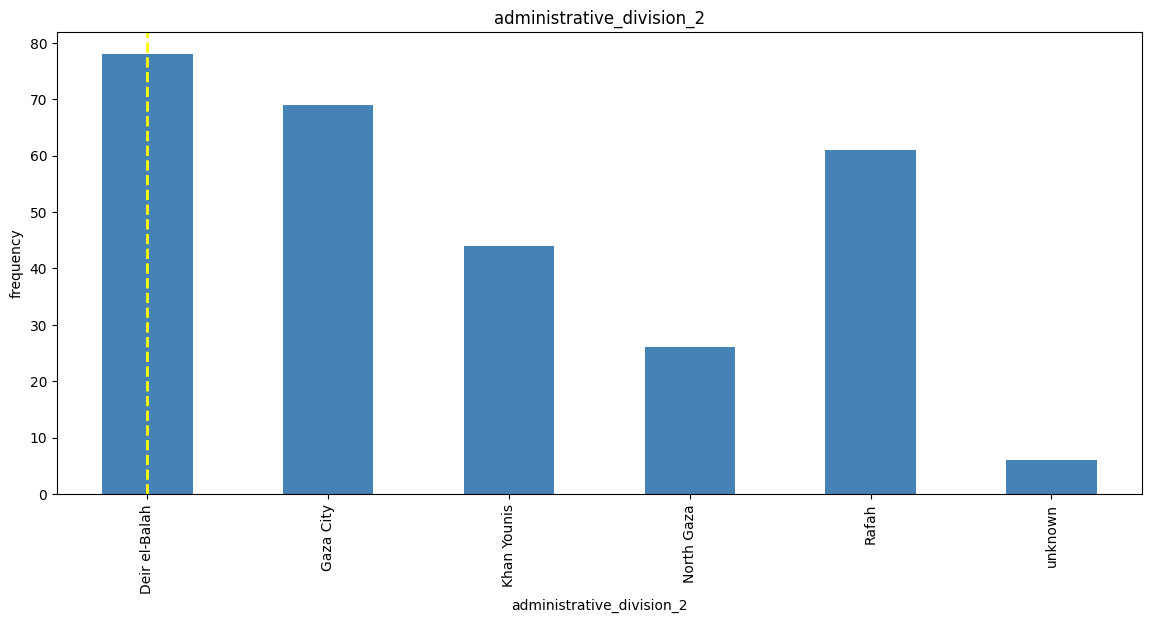

In [55]:
# what administrative_division_2 has the most food infrastructure attacks?
show_dist(df["administrative_division_2"])

Deir el-Balah has the most attacks and it is in the southern part of Gaza 
and from the plot we can see that Gaza city has more than 65 attacks coming directly after Deir el-Balah, Gaza city is considered in the northern part of Gaza
but to get a better answer to the question we are going to inspect each value in Admin 2 and specify weather it is southern or northern Gaza so that we can add up the number of attacks happening in the south and  the number of attacks happening in the north.

In [56]:
df["administrative_division_2"].value_counts()

administrative_division_2
Deir el-Balah    78
Gaza City        69
Rafah            61
Khan Younis      44
North Gaza       26
unknown           6
Name: count, dtype: int64

although Gaza city is in the northern part of Gaza and comes directly after Deir el-Balah in being the most attacked Admin 2 when it comes to food infrastructure, adding values up, most of the food infrastructure attacks are happening in the southern part of Gaza, with 183 total attacks in the southern part and 95 total attacks in the northern part and 6 unknown places.

**who is responsible for most of the attacks ?**
exploring the Reported Perpetrator Name column

Armed Forces of Israel


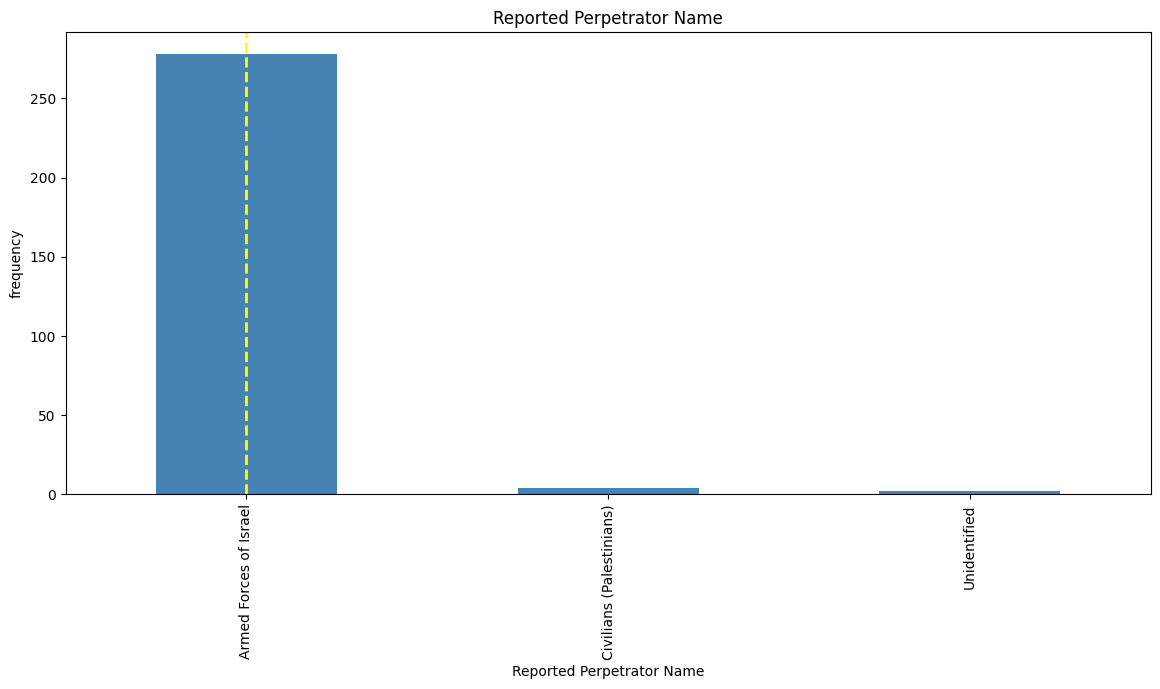

In [57]:
show_dist(df["Reported Perpetrator Name"])

from the plot we can see that most of the attacks were done by the Armed forces of Israel 
Armed forces of israel are responsible for more than 250 attacks out of a total of 284 
**who is responsible for most of the food infrastructure attacks in the southern part of Gaza?**


In [58]:
df.groupby("administrative_division_2")["Reported Perpetrator Name"].value_counts()

administrative_division_2  Reported Perpetrator Name
Deir el-Balah              Armed Forces of Israel       76
                           Civilians (Palestinians)      2
Gaza City                  Armed Forces of Israel       67
                           Unidentified                  2
Khan Younis                Armed Forces of Israel       44
North Gaza                 Armed Forces of Israel       26
Rafah                      Armed Forces of Israel       59
                           Civilians (Palestinians)      2
unknown                    Armed Forces of Israel        6
Name: count, dtype: int64

In the southern part of Gaza 179 attacks are done by the Armed Forces of Israel and only 4 by civilians.

exploring the most used method of attack 

Air or Drone Strike


Method of Attack
Air or Drone Strike                    176
Artillery, Shelling or Missile Fire     51
Firearms                                34
Unidentified                            15
Looting or Robbery                       4
Explosive                                2
Arson                                    1
Demolition                               1
Name: count, dtype: int64

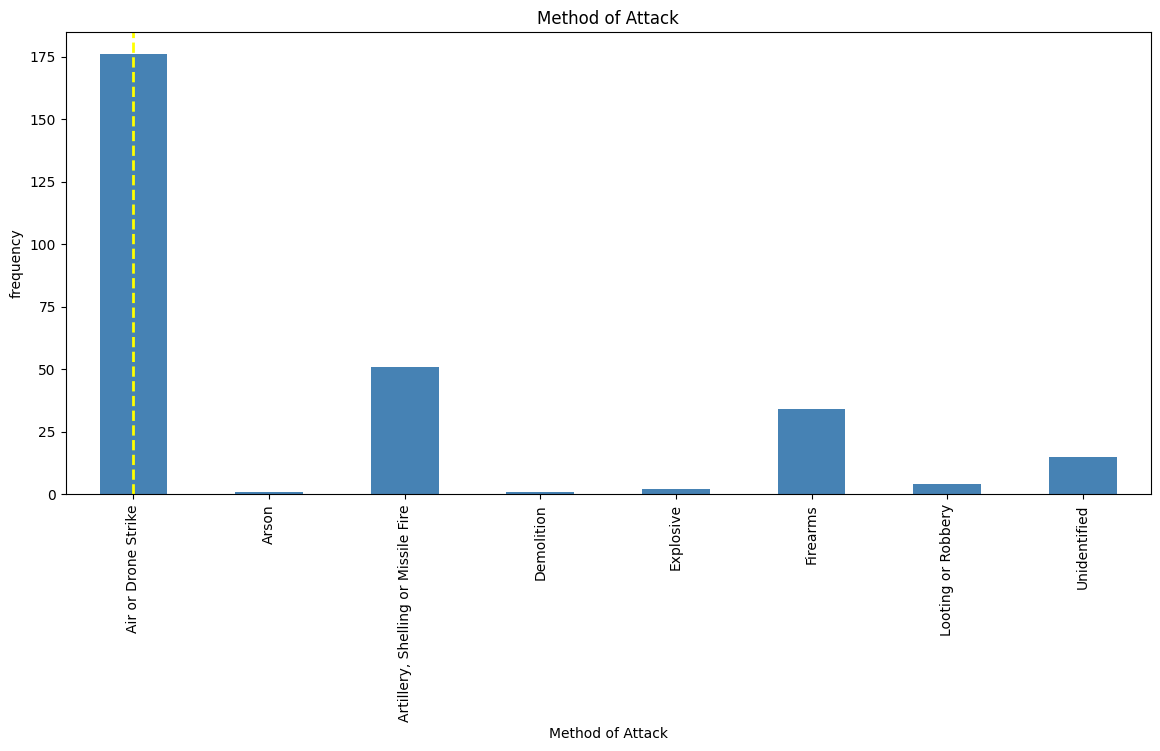

In [59]:
show_dist(df["Method of Attack"])
df["Method of Attack"].value_counts()

the most frequent attacking methods are 'Air or Drone Strike', 'Artillery, Shelling or Missile Fire',and Firearms.
we have 15 undefined attacking methods.

**what is the most attacked object?**
explore the object affected  column

Crops and Lands


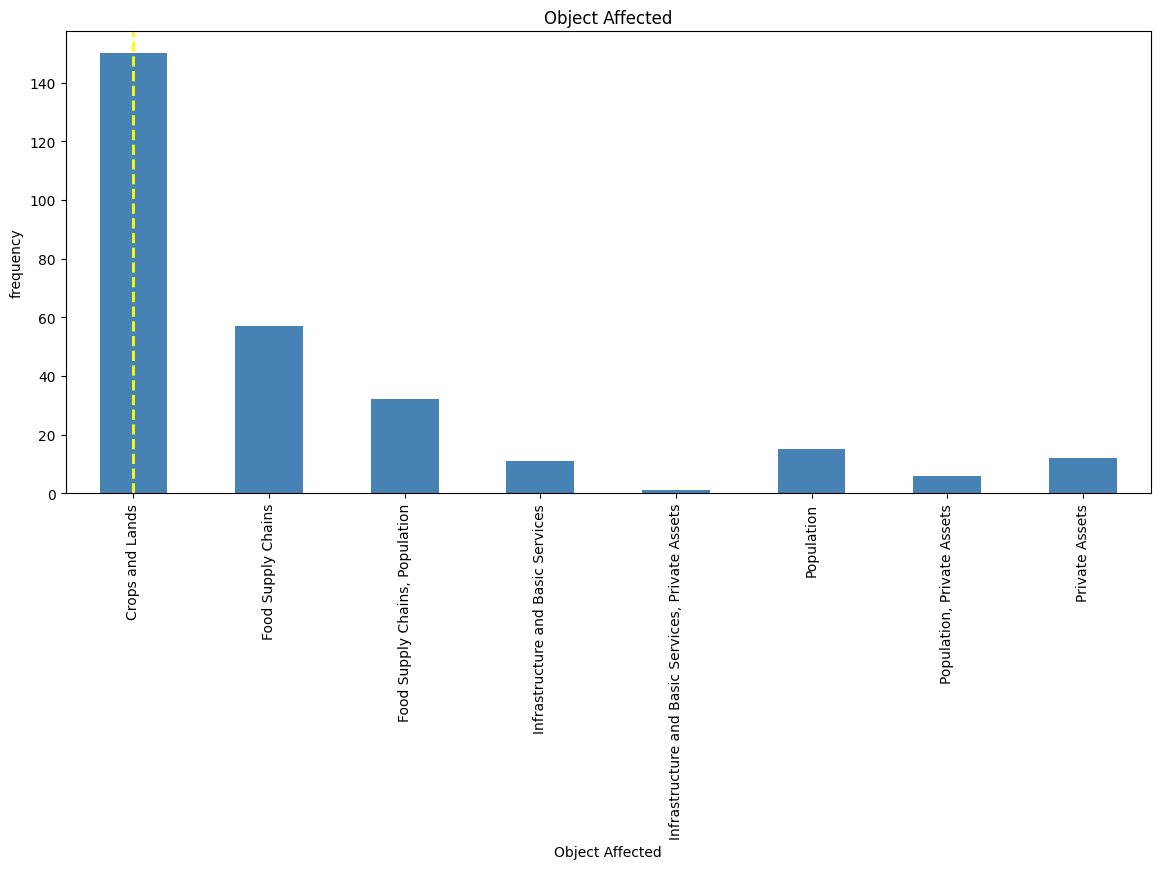

In [60]:
show_dist(df["Object Affected"])

the most affected objects are 'crops and lands', then, 'food supply chains', and lastly comes 'food supply chains,populations'.

In [61]:
df.groupby("Object Affected")["Sub-Object Affected"].value_counts()

Object Affected                                    Sub-Object Affected                  
Crops and Lands                                    Agricultural Land                        150
Food Supply Chains                                 Bakery                                    24
                                                   Market                                    24
                                                   Food Aid                                   4
                                                   Flour Mill                                 1
                                                   Food                                       1
                                                   Food Aid Truck                             1
                                                   Food Aid Warehouse                         1
                                                   Food Warehouse                             1
Food Supply Chains, Population                 

crops and lands is mainly AND ONLY 'Agricultural Land', 150 were affected
for the most sub-object affected within Food Supply Chains 24 bakeries and 24 markets were affected
Lastly, within 'Food Supply Chains, Population' there were 29 attacks towards People Waiting for or Receiving Aid  
**who exactly was responsible of these 29 attacks of People Waiting for or Receiving Aid?**

In [62]:
df.groupby("Sub-Object Affected")["Reported Perpetrator Name"].value_counts()
# df.groupby('Sub-Object Affected')['administrative_division_2'].value_counts()

Sub-Object Affected                    Reported Perpetrator Name
Agricultural Land                      Armed Forces of Israel       151
Bakery                                 Armed Forces of Israel        24
Farm                                   Armed Forces of Israel         3
Farmer/s                               Armed Forces of Israel         8
Fishers                                Armed Forces of Israel         6
Fishers, Fishing Boats                 Armed Forces of Israel         5
Fishing Boats                          Armed Forces of Israel         7
Fishing Boats, Fishers                 Armed Forces of Israel         1
Fishing Port                           Armed Forces of Israel         5
Fishing Port, Fishing Boats            Armed Forces of Israel         1
Flour Mill                             Armed Forces of Israel         1
Food                                   Civilians (Palestinians)       1
Food Aid                               Civilians (Palestinians)       3

28 out of 29 of attacks towards People Waiting for or Receiving Aid were done by the Armed Forces of Israel.

**from the period of July 2024 to september 2024, were most of the food infrastructure attacks southern or northern Gaza?**
first step we are going to create a sub data frame that only contains data from July 2024 up to September 2024

In [63]:
sem_data = df[df["Date"].between("2024-07-01", "2024-09-30")]
first_mention = sem_data["Date"].min()
print(first_mention)

2024-07-09 00:00:00


we have dates from 2024-07-09 up to 2024-09-16

Deir el-Balah


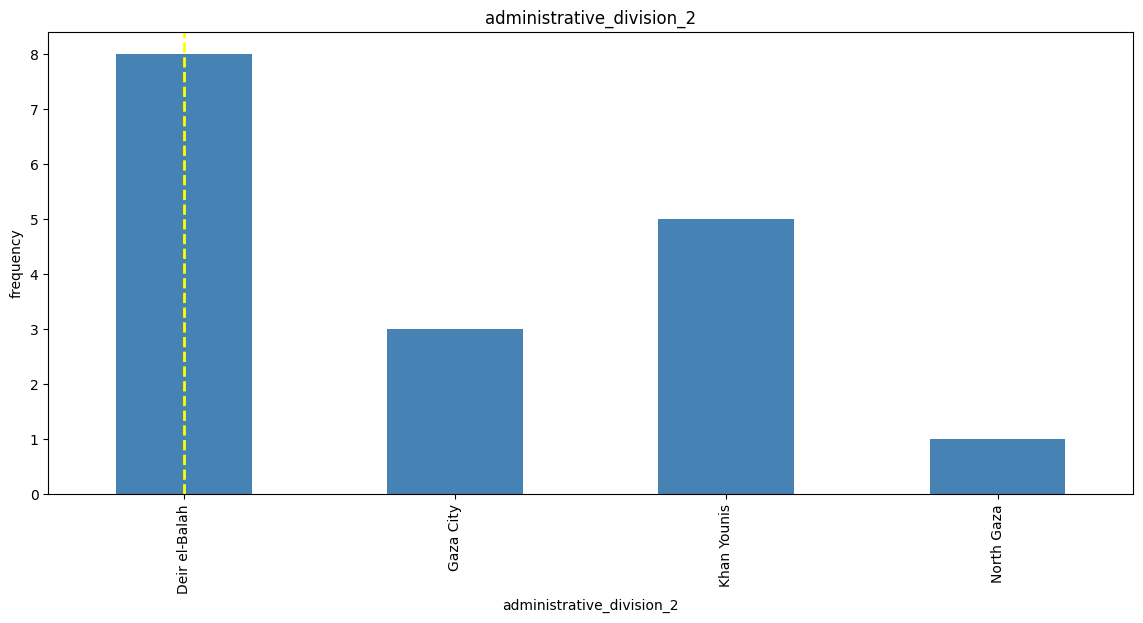

In [64]:
show_dist(sem_data["administrative_division_2"])

we can see even within this period of time most of the food infrastructure attacks happened in the southern part of Gaza, specifically 13 out of  17 attacks happened in the south:
Deir el-Balah: 8 attacks
Khan Younis: 5 attacks


**Who is responsible for most of the attacks that happened within this period (July-September 2024)?**

Armed Forces of Israel


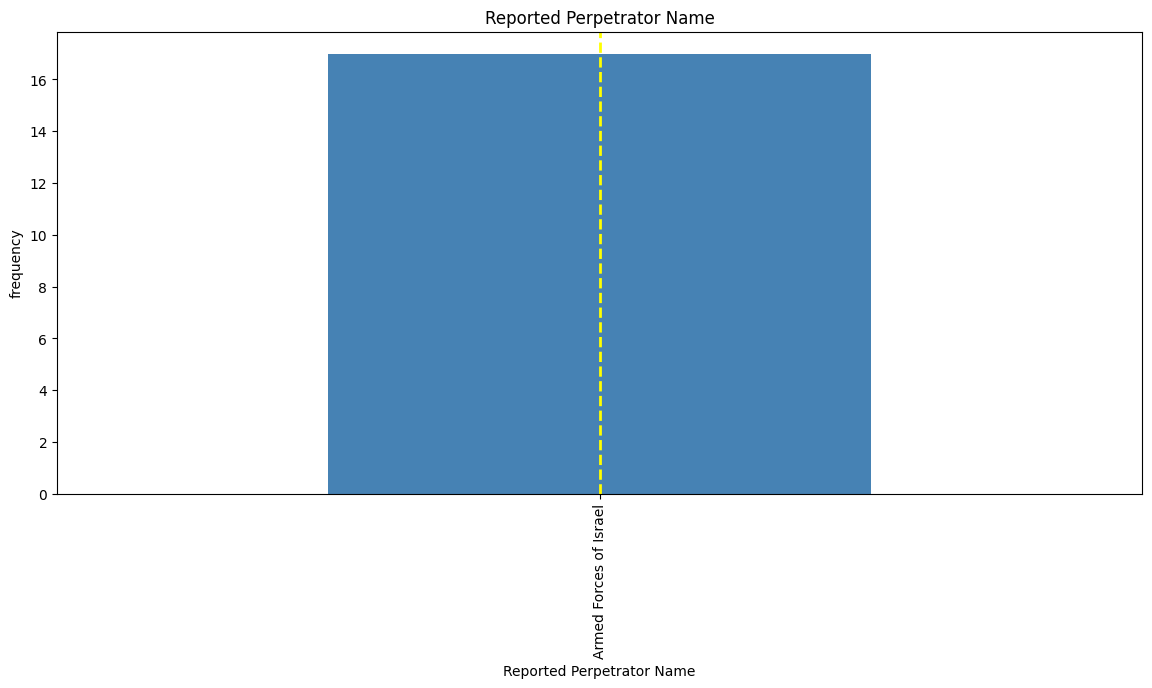

In [65]:
show_dist(sem_data["Reported Perpetrator Name"])

The party responsible of all of these attacks within this period of time is the Armed Forces of Israel.

let us check the most frequent Object Affected and Sub-Object Affected

Food Supply Chains


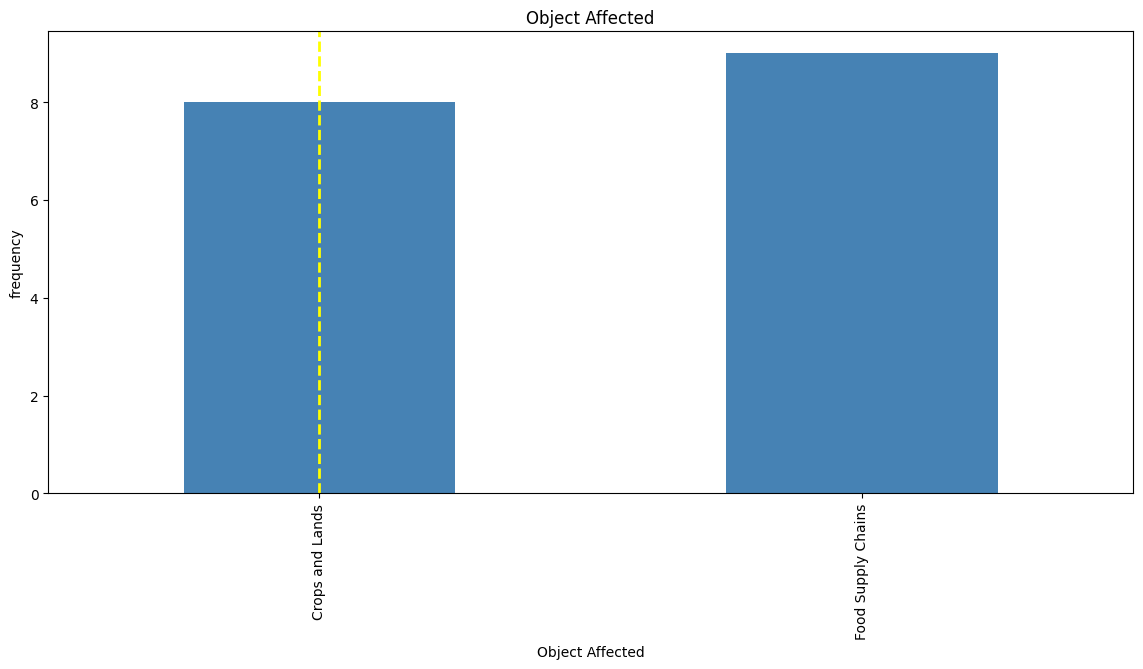

In [66]:
show_dist(sem_data["Object Affected"])

only two main objects got affected, Food Supply Chains(9) and Crops and Lands (8)
now let us check the most Sub-Object Affected

Agricultural Land


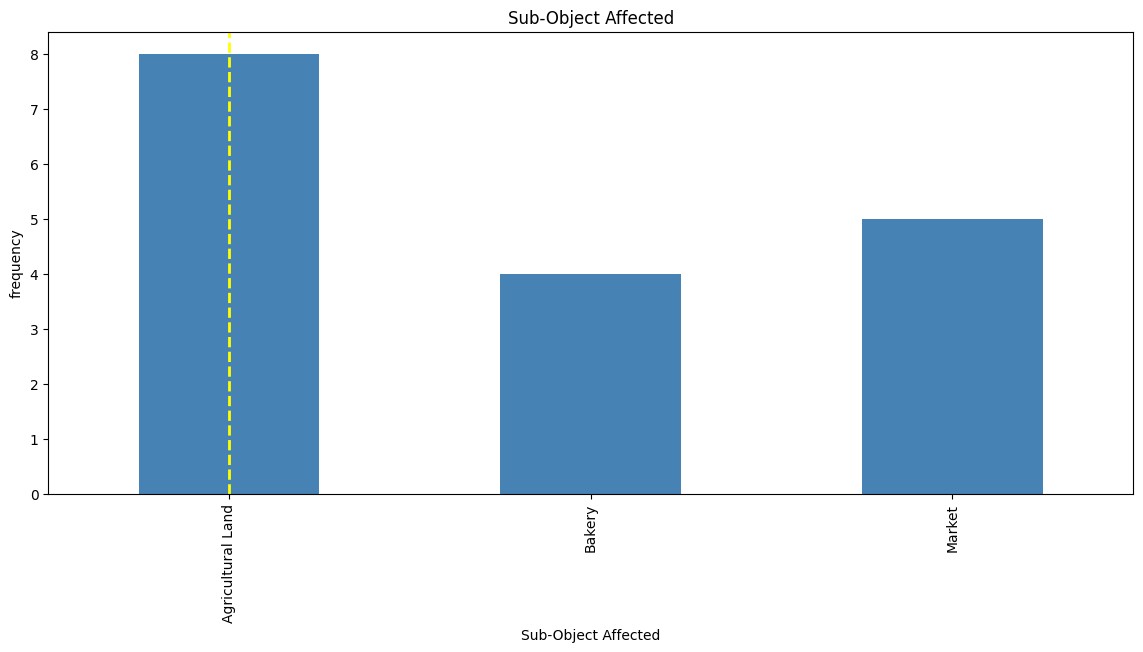

In [67]:
show_dist(sem_data["Sub-Object Affected"])

the most effected Sub-Object within the period of July to September 2024 is Agricultural Lands (8), then, markets (5), and lastly 4 bakeries were attacked 
**what is the most used method of attack?**

Air or Drone Strike


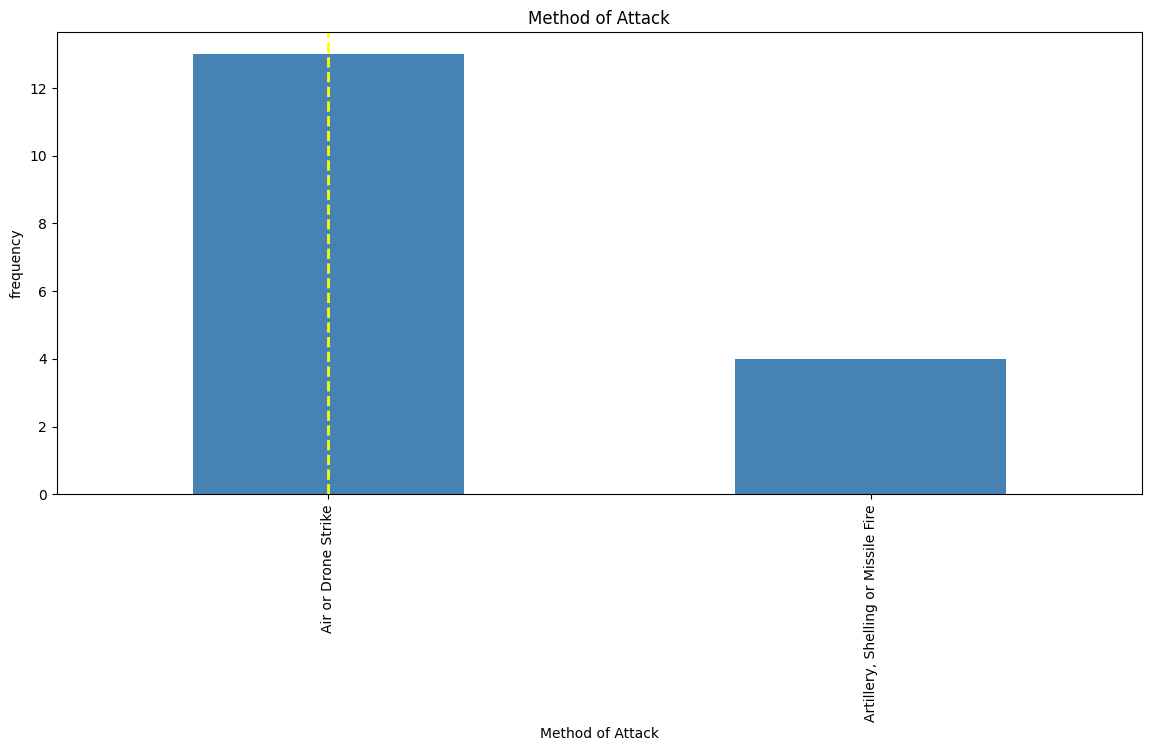

In [68]:
show_dist(sem_data["Method of Attack"])

the most used method of attack is  'Air or Drone Strike', with only 4 'Artillery, Shelling or Missile Fire' used 